In [11]:
%pip install sqlalchemy psycopg2-binary pandas matplotlib


Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt


In [13]:
import os
from dotenv import load_dotenv

# Use '../.env' because your notebook is in the 'notebooks/' subfolder
env_path = os.path.join('..', '.env')
load_dotenv(env_path)

# Verification
print(f"✅ Environment loaded: {load_dotenv(env_path)}")
print(f"Connecting to: {os.getenv('POSTGRES_DB')}")


✅ Environment loaded: True
Connecting to: olist_dw


In [14]:
from sqlalchemy import create_engine
import pandas as pd

# Create connection
# Updated connection line
engine = create_engine(f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}")

# Load FactSales for "Monthly Sales Trends"
df_sales = pd.read_sql("SELECT * FROM analytics.fact_sales", engine)
df_sales['purchased_at'] = pd.to_datetime(df_sales['purchased_at'])

# Calculate Trend
monthly_revenue = df_sales.resample('M', on='purchased_at')['total_sale_amount'].sum()
print(monthly_revenue.tail())


purchased_at
2018-05-31    1149781.82
2018-06-30    1022677.11
2018-07-31    1058728.03
2018-08-31    1003308.47
2018-09-30        166.46
Freq: ME, Name: total_sale_amount, dtype: float64


/tmp/ipykernel_140560/3979191642.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df_sales.resample('M', on='purchased_at')['total_sale_amount'].sum()


In [15]:
# 1. Load Data
df_sales = pd.read_sql("SELECT * FROM analytics.fact_sales", engine)
df_products = pd.read_sql("SELECT * FROM analytics.dim_products", engine)
df_sales['purchased_at'] = pd.to_datetime(df_sales['purchased_at'])

In [16]:

# 2. Monthly Sales Trends (Requirement 5a)
monthly_revenue = df_sales.resample('M', on='purchased_at')['total_sale_amount'].sum()
print("📈 Monthly Trends:\n", monthly_revenue.tail())

📈 Monthly Trends:
 purchased_at
2018-05-31    1149781.82
2018-06-30    1022677.11
2018-07-31    1058728.03
2018-08-31    1003308.47
2018-09-30        166.46
Freq: ME, Name: total_sale_amount, dtype: float64


/tmp/ipykernel_140560/1918484175.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df_sales.resample('M', on='purchased_at')['total_sale_amount'].sum()


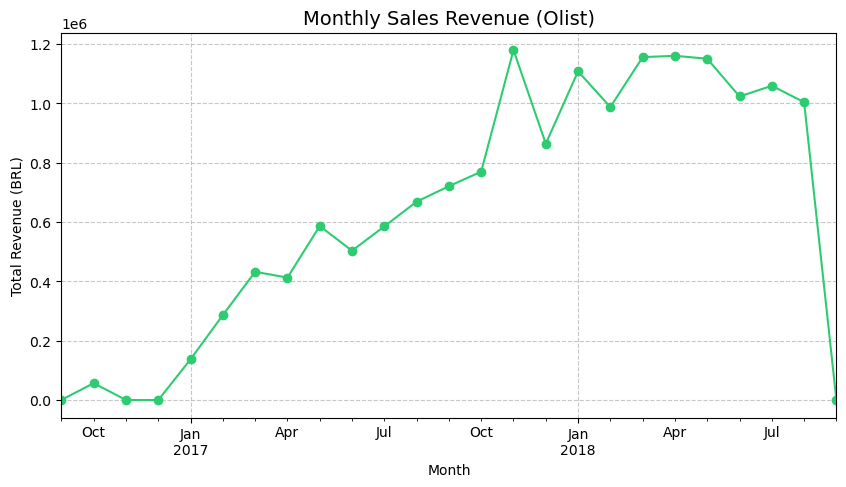

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
monthly_revenue.plot(kind='line', marker='o', color='#2ecc71')
plt.title('Monthly Sales Revenue (Olist)', fontsize=14)
plt.ylabel('Total Revenue (BRL)')
plt.xlabel('Month')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [18]:

# 3. Top-Selling Products (Requirement 5b)
# Merge sales with products to get category names
top_products = df_sales.merge(df_products, on='product_id')
top_categories = top_products.groupby('product_category')['total_sale_amount'].sum().sort_values(ascending=False).head(5)
print("\n🏆 Top 5 Categories:\n", top_categories)


🏆 Top 5 Categories:
 product_category
health_beauty            1441248.07
watches_gifts            1305541.61
bed_bath_table           1241681.72
sports_leisure           1156656.48
computers_accessories    1059272.40
Name: total_sale_amount, dtype: float64


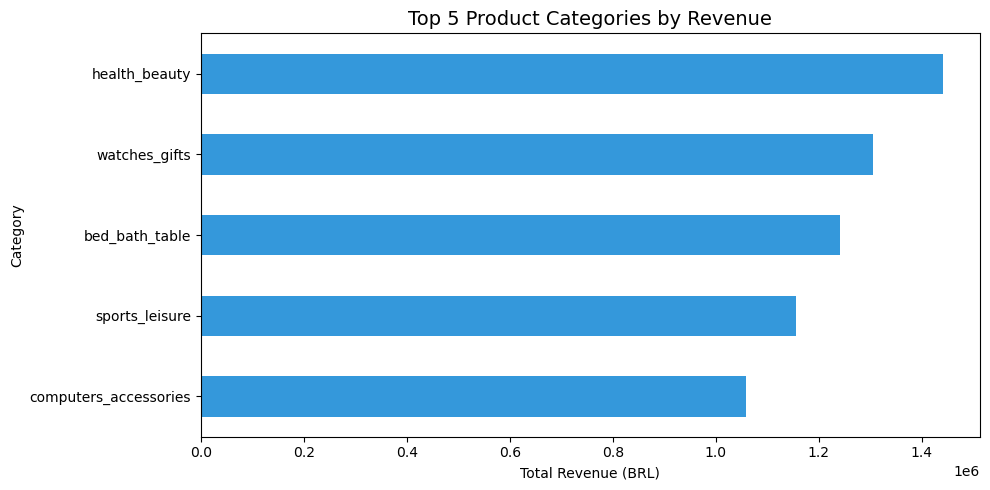

In [19]:
plt.figure(figsize=(10, 5))
top_categories.sort_values().plot(kind='barh', color='#3498db')
plt.title('Top 5 Product Categories by Revenue', fontsize=14)
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


💎 Identification complete: 16298 Champion Customers found.


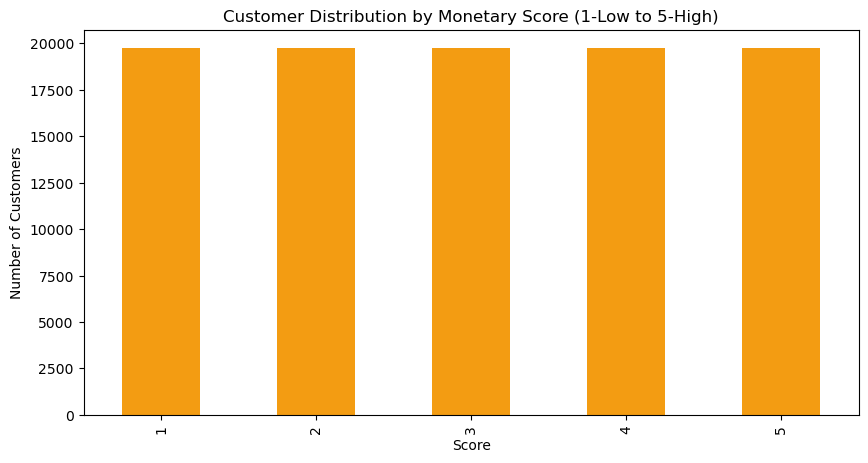

In [ ]:
# # 4. Advanced RFM Customer Segmentation
# Define the reference date as the last purchase in the dataset + 1 day
reference_date = df_sales['purchased_at'].max() + pd.Timedelta(days=1)

# Calculate Recency, Frequency, and Monetary
rfm = df_sales.groupby('customer_id').agg({
    'purchased_at': lambda x: (reference_date - x.max()).days, # Recency
    'order_id': 'count',                                     # Frequency
    'total_sale_amount': 'sum'                               # Monetary
})

rfm.columns = ['recency', 'frequency', 'monetary']

# Advanced Scoring (Quintiles 1-5)
# R_score: 5 is best (most recent), 1 is worst
rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])
# F & M scores: 5 is best (highest freq/spend)
rfm['f_score'] = rfm['frequency'].rank(method='first').pipe(pd.qcut, 5, labels=[1, 2, 3, 4, 5])
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5])

# Identify "Champions" (Highest scores in all categories)
champions = rfm[(rfm['r_score'].astype(int) >= 4) & (rfm['m_score'].astype(int) >= 4)]
print(f"💎 Identification complete: {len(champions)} Champion Customers found.")

# Visualize the distribution of Monetary value across segments
# 1. Calculate TOTAL REVENUE per score instead of just counting people
revenue_by_score = rfm.groupby('m_score')['monetary'].sum()

# 2. Setup the visual
plt.figure(figsize=(12, 6))
# Professional gradient: Light to Dark (Executive-friendly)
colors = ['#fdebd0', '#fad7a0', '#f8c471', '#f39c12', '#d35400'] 

# 3. Create the bar chart
revenue_by_score.plot(kind='bar', color=colors, edgecolor='black', alpha=0.9)

# 4. Add "Executive-Ready" styling
plt.title('Revenue Impact by Customer Spend Segment', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Monetary Score (1 = Low Spend, 5 = High Spend)', fontsize=12)
plt.ylabel('Total Revenue (BRL)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. THE "COLLABORATION CATALYST" TOUCH: 
# Automatically calculate an insight to display on the chart
top_tier_pct = (revenue_by_score.iloc[-1] / revenue_by_score.sum()) * 100
plt.annotate(f'Strategic Insight:\nScore 5 customers contribute\n{top_tier_pct:.1f}% of total revenue.', 
             xy=(4, revenue_by_score.iloc[-1]), 
             xytext=(1, revenue_by_score.max()*0.8),
             fontsize=11, color='red', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.tight_layout()
plt.show()


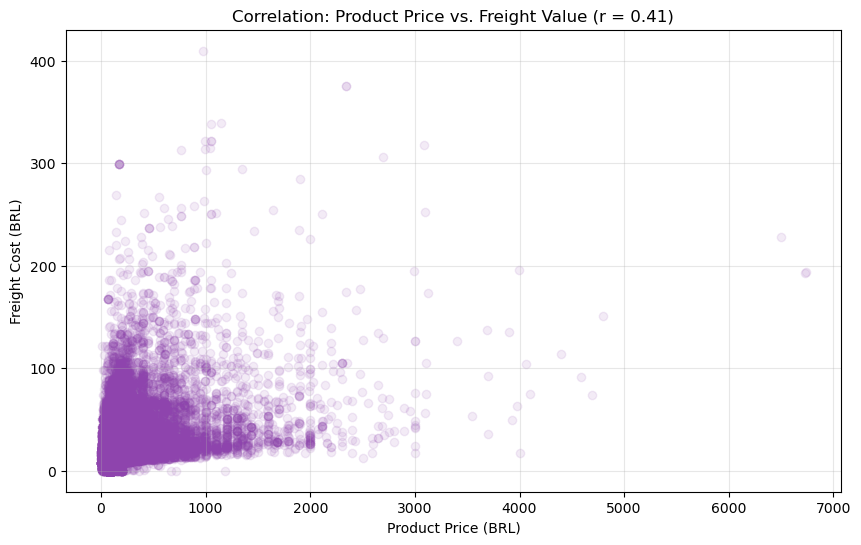

📊 Insight: The correlation is 0.41. If low, it suggests freight is driven by distance/weight more than value.


In [21]:
# # 5. Curious Insight: Logistics & Revenue Correlation
# Do expensive products have higher shipping costs? 
correlation = df_sales['price'].corr(df_sales['freight_value'])

plt.figure(figsize=(10, 6))
plt.scatter(df_sales['price'], df_sales['freight_value'], alpha=0.1, color='#8e44ad')
plt.title(f'Correlation: Product Price vs. Freight Value (r = {correlation:.2f})')
plt.xlabel('Product Price (BRL)')
plt.ylabel('Freight Cost (BRL)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"📊 Insight: The correlation is {correlation:.2f}. If low, it suggests freight is driven by distance/weight more than value.")


Business Recommendations
Retention: Our RFM analysis identified a specific "Champion" group. We should offer them exclusive "First Access" to new product launches to maintain loyalty.
Logistics: The Price vs. Freight scatter plot shows significant outliers. We should investigate the shipping partners for the high-freight/low-price items to optimize margins.
Inventory: Focus marketing spend on the Top 5 Categories (identified in Section 3) during the peak months found in the Monthly Trends (Section 2).